In [6]:
import os
print(os.getcwd()) 


C:\Users\Lenovo\OneDrive\Desktop\Jupyter Projects


In [7]:
# import libraries & load data
import pandas as pd
import numpy as np

# Load datasets
matches = pd.read_csv("matches.csv")
deliveries = pd.read_csv("deliveries.csv")

print("Matches Shape:", matches.shape)
print("Deliveries Shape:", deliveries.shape) 

Matches Shape: (1095, 20)
Deliveries Shape: (260920, 17)


In [8]:
#Check Missing Values 
print("\nMissing Values in Matches Dataset:\n")
print(matches.isnull().sum())

print("\nMissing Values in Deliveries Dataset:\n")
print(deliveries.isnull().sum()) 


Missing Values in Matches Dataset:

id                    0
season                0
city                 51
date                  0
match_type            0
player_of_match       5
venue                 0
team1                 0
team2                 0
toss_winner           0
toss_decision         0
winner                5
result                0
result_margin        19
target_runs           3
target_overs          3
super_over            0
method             1074
umpire1               0
umpire2               0
dtype: int64

Missing Values in Deliveries Dataset:

match_id                 0
inning                   0
batting_team             0
bowling_team             0
over                     0
ball                     0
batter                   0
bowler                   0
non_striker              0
batsman_runs             0
extra_runs               0
total_runs               0
extras_type         246795
is_wicket                0
player_dismissed    247970
dismissal_kind      24797

In [9]:
# HANDLE MISSING VALUES(MATCHES DATASET) 
# Fill missing city values with 'Unknown'
matches['city'] = matches['city'].fillna("Unknown")

# Fill missing winner with 'No Result'
matches['winner'] = matches['winner'].fillna("No Result")

# Fill missing player_of_match with 'Not Awarded'
matches['player_of_match'] = matches['player_of_match'].fillna("Not Awarded")

# Fill missing toss_decision with mode (most common value)
matches['toss_decision'] = matches['toss_decision'].fillna(
    matches['toss_decision'].mode()[0]
) 

In [9]:
matches[['city','winner','player_of_match','toss_decision']].isnull().sum() 

city               0
winner             0
player_of_match    0
toss_decision      0
dtype: int64

In [10]:
# HANDLE MISSING VALUES (DELIVERIES DATASET) 
# Replace NaN in player_dismissed with 'Not Out'
deliveries['player_dismissed'] = deliveries['player_dismissed'].fillna("Not Out") 

In [21]:
 # REMOVE DUPLICATE ROWS 
matches.drop_duplicates(inplace=True) 
deliveries.drop_duplicates(inplace=True) 
print("After removing duplicates:")
print("Matches Shape:", matches.shape)
print("Deliveries Shape:", deliveries.shape) 

After removing duplicates:
Matches Shape: (1095, 21)
Deliveries Shape: (260920, 17)


In [13]:
# Standardize team names 
matches['team1'] = matches['team1'].replace({
    'Delhi Daredevils': 'Delhi Capitals'
})

matches['team2'] = matches['team2'].replace({
    'Delhi Daredevils': 'Delhi Capitals'
})

matches['winner'] = matches['winner'].replace({
    'Delhi Daredevils': 'Delhi Capitals'
})

deliveries['batting_team'] = deliveries['batting_team'].replace({
    'Delhi Daredevils': 'Delhi Capitals'
})

deliveries['bowling_team'] = deliveries['bowling_team'].replace({
    'Delhi Daredevils': 'Delhi Capitals'
}) 

In [14]:
# CONVERT DATA TYPES
# Convert date column to datetime (handle errors safely)
matches['date'] = pd.to_datetime(matches['date'], errors='coerce')

# Ensure season column is integer (handle '2007/08' format)
matches['season'] = matches['season'].astype(str).str[:4].astype(int) 

C:\Users\Lenovo\AppData\Local\Temp\ipykernel_16076\137838808.py:2: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  matches['date'] = pd.to_datetime(matches['date'], errors='coerce')


In [16]:
print(matches[['season','date']].head()) 

   season       date
0    2007 2008-04-18
1    2007 2008-04-19
2    2007 2008-04-19
3    2007 2008-04-20
4    2007 2008-04-20


In [17]:
#CREATE NEW USEFUL COLUMNS 
#TOSS WIN INDICATOR 
matches['toss_match_win'] = matches['toss_winner'] == matches['winner'] 

In [19]:
#TOTAL RUNS PER BALL 
deliveries['total_runs'] = pd.to_numeric(deliveries['total_runs'], errors='coerce') 

In [20]:
#FINAL CHECK 
print("\nFinal Matches Info:\n")
print(matches.info())

print("\nFinal Deliveries Info:\n")
print(deliveries.info()) 


Final Matches Info:

<class 'pandas.DataFrame'>
RangeIndex: 1095 entries, 0 to 1094
Data columns (total 21 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   id               1095 non-null   int64         
 1   season           1095 non-null   int64         
 2   city             1095 non-null   str           
 3   date             1095 non-null   datetime64[us]
 4   match_type       1095 non-null   str           
 5   player_of_match  1095 non-null   str           
 6   venue            1095 non-null   str           
 7   team1            1095 non-null   str           
 8   team2            1095 non-null   str           
 9   toss_winner      1095 non-null   str           
 10  toss_decision    1095 non-null   str           
 11  winner           1095 non-null   str           
 12  result           1095 non-null   str           
 13  result_margin    1076 non-null   float64       
 14  target_runs      1092 non-nul

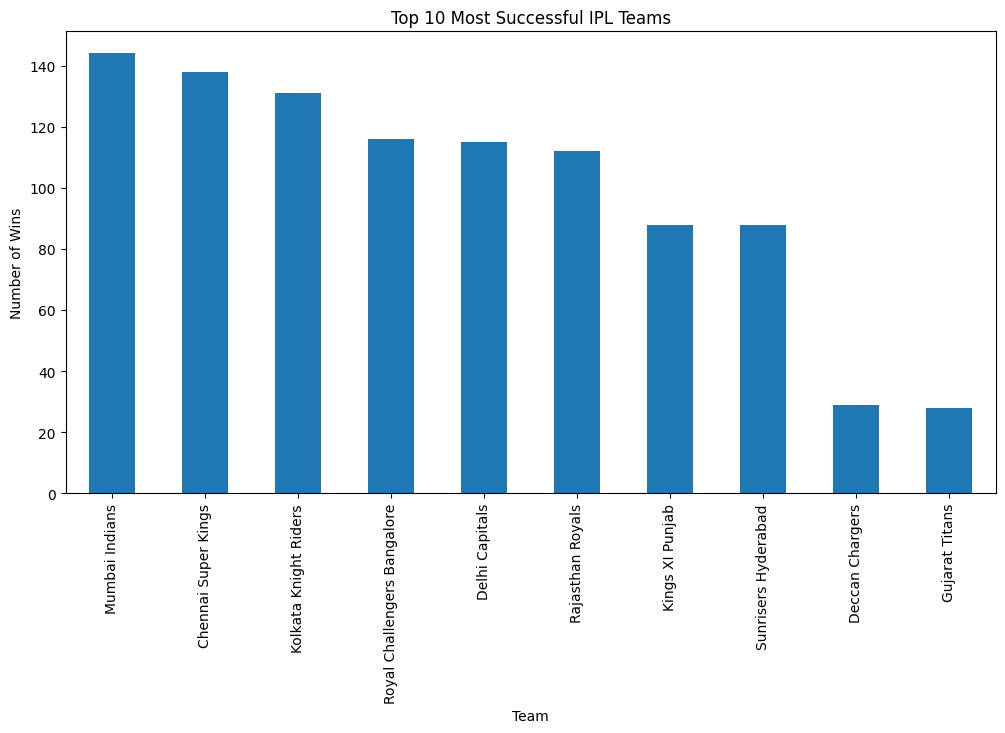

In [22]:
#Most Successful Teams in IPL History 
import matplotlib.pyplot as plt
plt.figure(figsize=(12,6))
matches['winner'].value_counts().head(10).plot(kind='bar')
plt.title("Top 10 Most Successful IPL Teams")
plt.xlabel("Team")
plt.ylabel("Number of Wins")
plt.xticks(rotation=90)
plt.show() 

In [21]:
!pip install matplotlib

   ---------------------------------------- 0.0/8.3 MB ? eta -:--:--
   --- ------------------------------------ 0.8/8.3 MB 6.1 MB/s eta 0:00:02
   -------- ------------------------------- 1.8/8.3 MB 4.4 MB/s eta 0:00:02
   ------------ --------------------------- 2.6/8.3 MB 4.2 MB/s eta 0:00:02
   ---------------- ----------------------- 3.4/8.3 MB 4.1 MB/s eta 0:00:02
   --------------------- ------------------ 4.5/8.3 MB 4.1 MB/s eta 0:00:01
   ------------------------- -------------- 5.2/8.3 MB 4.0 MB/s eta 0:00:01
   ----------------------------- ---------- 6.0/8.3 MB 4.0 MB/s eta 0:00:01
   ------------------------------- -------- 6.6/8.3 MB 4.0 MB/s eta 0:00:01
   ------------------------------------ --- 7.6/8.3 MB 4.0 MB/s eta 0:00:01
   ---------------------------------------- 8.3/8.3 MB 3.9 MB/s  0:00:02
   ---------------------------------------- 0.0/2.3 MB ? eta -:--:--
   ------------- -------------------------- 0.8/2.3 MB 3.9 MB/s eta 0:00:01
   --------------------------

Percentage of matches where toss winner also won: 47.397260273972606


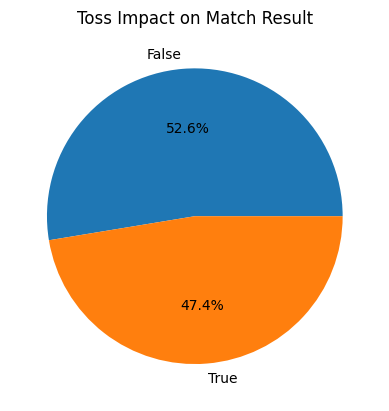

In [23]:
#Toss Impact on Match Result
matches['toss_win_match'] = matches['toss_winner'] == matches['winner']
toss_percentage = matches['toss_win_match'].mean() * 100

print("Percentage of matches where toss winner also won:", toss_percentage)

matches['toss_win_match'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Toss Impact on Match Result")
plt.show() 

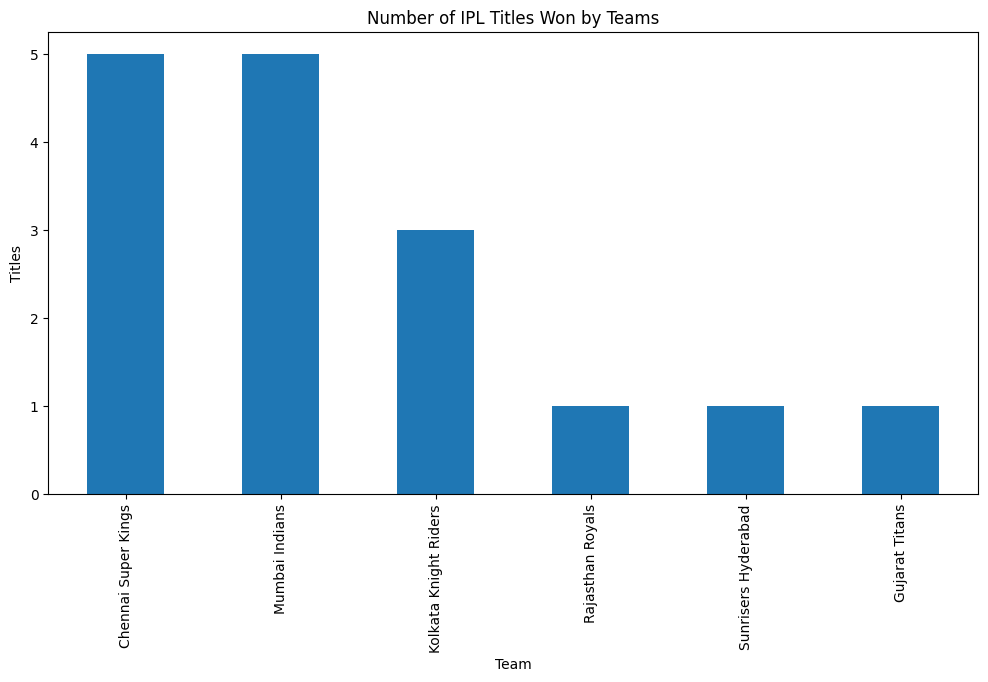

In [24]:
#Season-wise IPL Winners
season_winners = matches.groupby('season')['winner'].last()

plt.figure(figsize=(12,6))
season_winners.value_counts().plot(kind='bar')
plt.title("Number of IPL Titles Won by Teams")
plt.xlabel("Team")
plt.ylabel("Titles")
plt.xticks(rotation=90)
plt.show() 

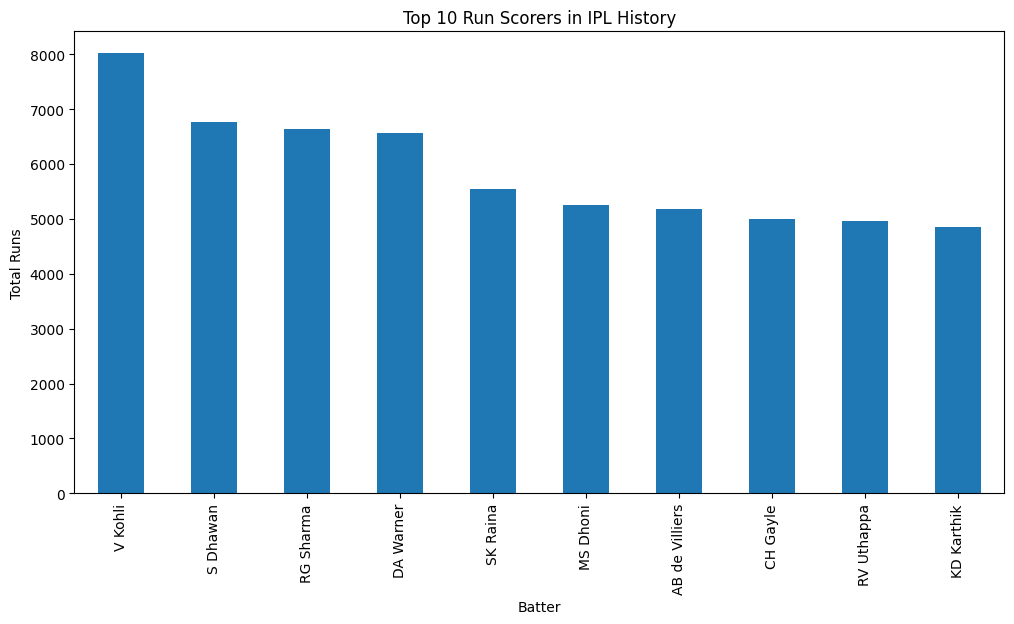

In [27]:
#Top 10 Run Scorers (All Time)
top_runs = deliveries.groupby('batter')['batsman_runs'].sum() \
                     .sort_values(ascending=False) \
                     .head(10)

plt.figure(figsize=(12,6))
top_runs.plot(kind='bar')
plt.title("Top 10 Run Scorers in IPL History")
plt.xlabel("Batter")
plt.ylabel("Total Runs")
plt.xticks(rotation=90)
plt.show() 


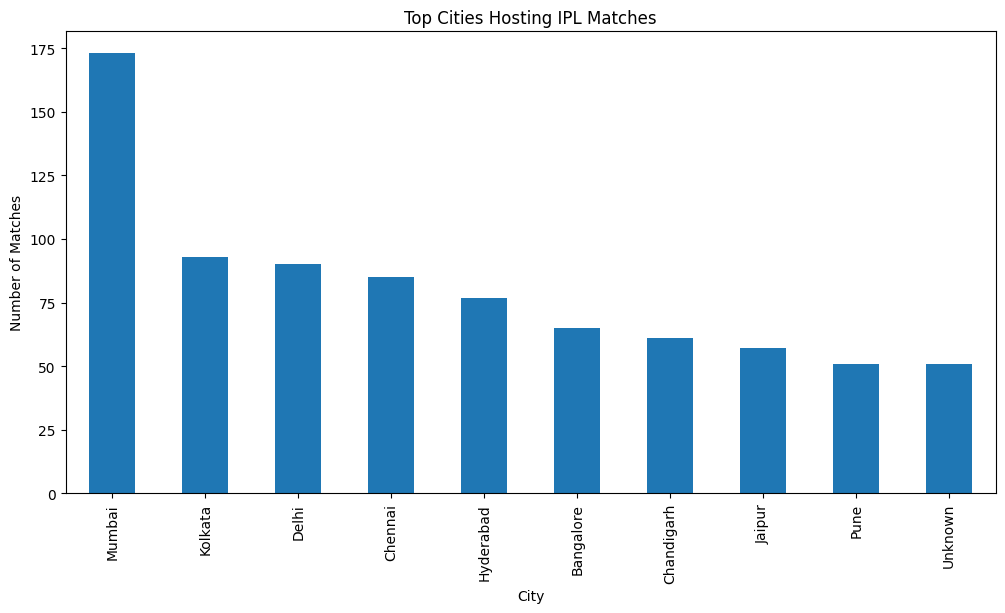

In [28]:
#Matches Hosted by Cities
plt.figure(figsize=(12,6))
matches['city'].value_counts().head(10).plot(kind='bar')
plt.title("Top Cities Hosting IPL Matches")
plt.xlabel("City")
plt.ylabel("Number of Matches")
plt.xticks(rotation=90)
plt.show() 

In [30]:
!pip install seaborn

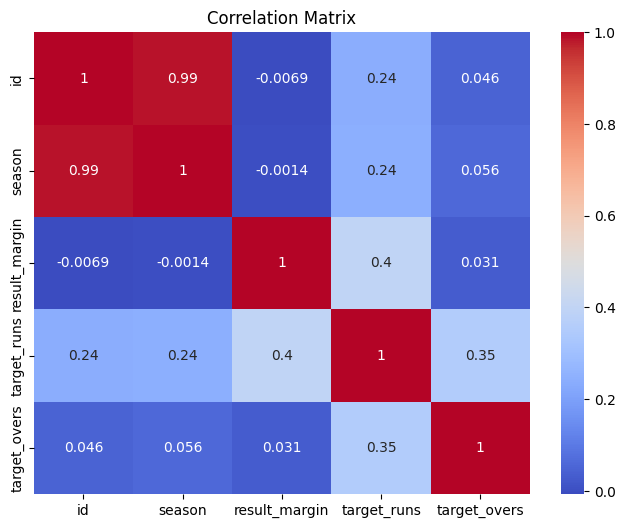

In [34]:
#Correlation Heatmap
import matplotlib.pyplot as plt
import seaborn as sns

# Select only numeric columns
numeric_cols = matches.select_dtypes(include=['int64','float64'])

# Create correlation heatmap
plt.figure(figsize=(8,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show() 

In [38]:
# FEATURE ENGINEERING (MEANS CREATING NEW USEFUL COLUMNS FROM EXISTING DATA)
# Total matches played by each team
total_matches_team1 = matches['team1'].value_counts()
total_matches_team2 = matches['team2'].value_counts()

total_matches = total_matches_team1.add(total_matches_team2, fill_value=0)

print(total_matches.sort_values(ascending=False).head()) 

team1
Mumbai Indians                 261
Delhi Capitals                 252
Kolkata Knight Riders          251
Royal Challengers Bangalore    240
Chennai Super Kings            238
Name: count, dtype: int64


In [42]:
# FEATURE ENGINEERING (MEANS CREATING NEW USEFUL COLUMNS FROM EXISTING DATA) 
# 1️⃣ Total runs conceded by each bowler (includes extras automatically)
runs_conceded = deliveries.groupby('bowler')['total_runs'].sum()

# 2️⃣ Count total balls bowled
balls_bowled = deliveries.groupby('bowler')['ball'].count()

# 3️⃣ Calculate economy rate
economy = (runs_conceded / balls_bowled) * 6

# 4️⃣ Convert to DataFrame
economy = economy.reset_index()
economy.columns = ['Bowler', 'Economy Rate']

# 5️⃣ Show Top 10 Best Economy (Lowest)
economy.sort_values(by='Economy Rate').head(10) 

,Bowler,Economy Rate
24,AC Gilchrist,0.000000
364,R Ravindra,3.500000
317,NB Singh,4.320000
460,Sachin Baby,4.800000
38,AM Rahane,5.000000
245,LA Carseldine,5.142857
453,SS Mundhe,5.142857
125,DJ Thornely,5.454545
260,M Manhas,6.000000
296,MW Short,6.000000


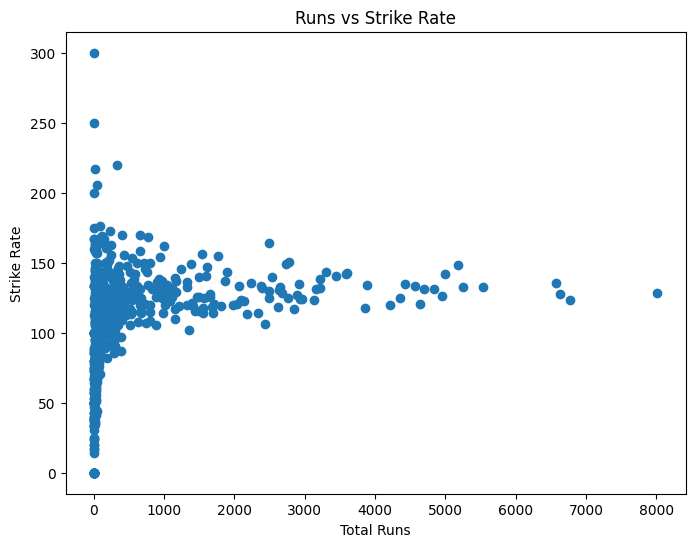

In [24]:
# STRIKE RATE OF BATSMEN 
# Calculate runs
!pip install matplotlib 
import matplotlib.pyplot as plt 
runs = deliveries.groupby('batter')['batsman_runs'].sum()

# Calculate balls faced
balls = deliveries.groupby('batter')['ball'].count()

# Strike rate
strike_rate = (runs / balls) * 100

df_sr = strike_rate.reset_index()
df_sr.columns = ['Player', 'Strike Rate']
df_sr['Total Runs'] = runs.values

plt.figure(figsize=(8,6))
plt.scatter(df_sr['Total Runs'], df_sr['Strike Rate'])
plt.title("Runs vs Strike Rate")
plt.xlabel("Total Runs")
plt.ylabel("Strike Rate")
plt.show() 

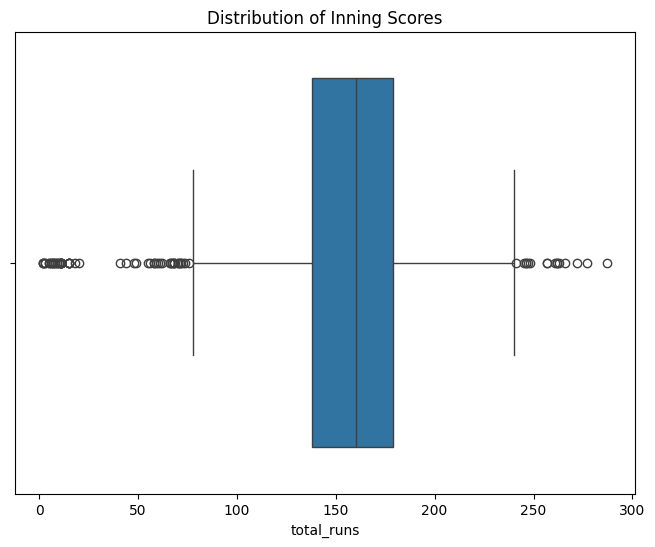

In [45]:
#Box Plot – Distribution of Match Scores 
match_scores = deliveries.groupby(['match_id','inning'])['total_runs'].sum().reset_index()

plt.figure(figsize=(8,6))
sns.boxplot(x=match_scores['total_runs'])
plt.title("Distribution of Inning Scores")
plt.show() 

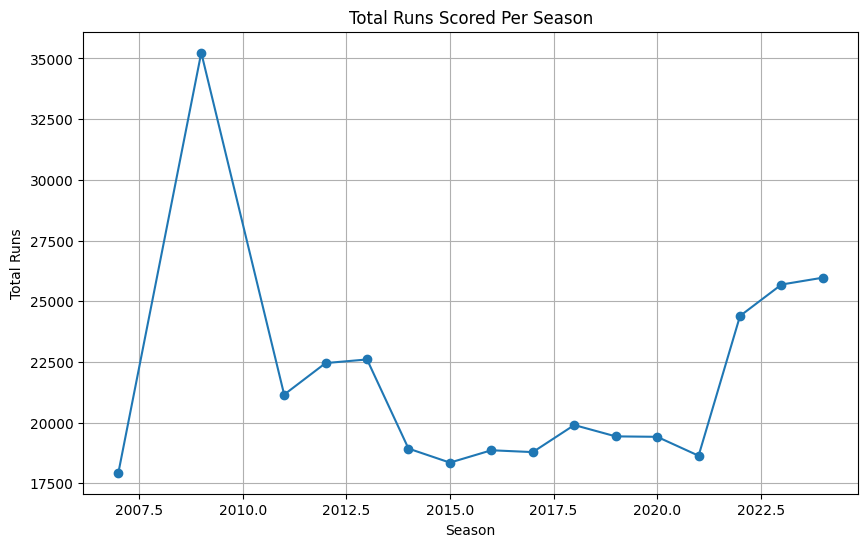

In [46]:
#Line Plot – Runs Trend Over Seasons 
import matplotlib.pyplot as plt
import seaborn as sns

# Total runs per season
season_runs = matches.merge(deliveries, left_on='id', right_on='match_id')
season_runs = season_runs.groupby('season')['total_runs'].sum()

plt.figure(figsize=(10,6))
plt.plot(season_runs.index, season_runs.values, marker='o')
plt.title("Total Runs Scored Per Season")
plt.xlabel("Season")
plt.ylabel("Total Runs")
plt.grid(True)
plt.show() 

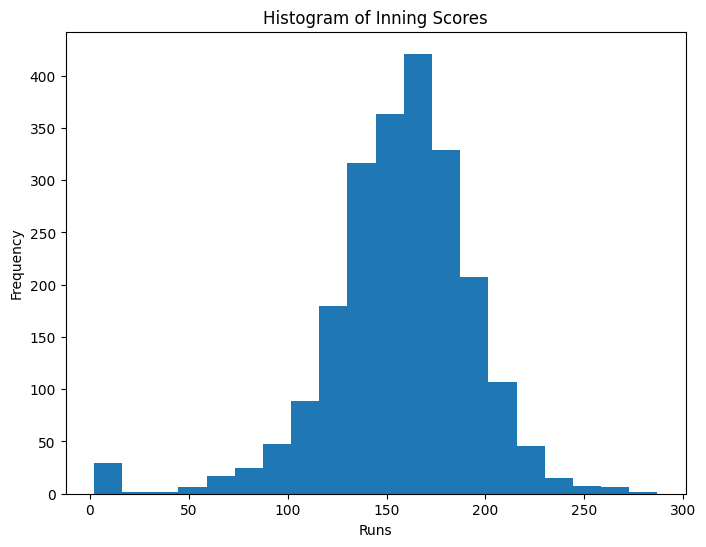

In [47]:
#Histogram – Frequency of Match Scores 
plt.figure(figsize=(8,6))
plt.hist(match_scores['total_runs'], bins=20)
plt.title("Histogram of Inning Scores")
plt.xlabel("Runs")
plt.ylabel("Frequency")
plt.show() 

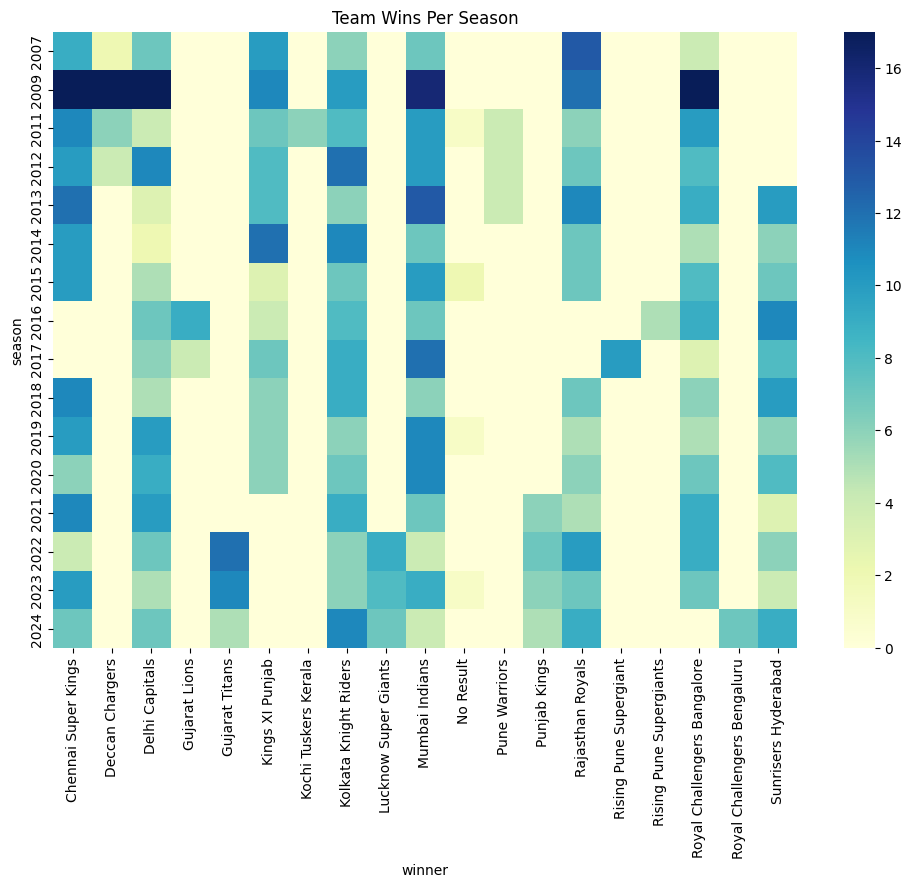

In [26]:
!pip install matplotlib 
import matplotlib.pyplot as plt 
!pip install seaborn 
import seaborn as sns 
#Heatmap – Wins by Team Per Season
wins_per_season = matches.pivot_table(
    index='season',
    columns='winner',
    aggfunc='size',
    fill_value=0
)

plt.figure(figsize=(12,8))
sns.heatmap(wins_per_season, cmap='YlGnBu')
plt.title("Team Wins Per Season")
plt.show() 